<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=5><B> Ollama实验(郑海超)</B></font></td></tr></table>

# install ollama

In [1]:
!pip install ollama

Looking in indexes: https://pypi.org/simple/
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 2.1 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.0 MB 2.0 MB/s eta 0:00:01
   ------------------------------- -------- 1.6/2.0 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 2.0 MB/s eta 0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.20.1
    Uninstalling pydantic_core-2.20.1:
      Successfully uninstalled pydantic_core-

[ollama下载大模型](https://ai4science.feishu.cn/wiki/F0bLw2kcUiwtfakakJncRTJAnUd)

# 下载大模型

ollama run model_name

https://ollama.com/search

# 在图形界面使用大模型



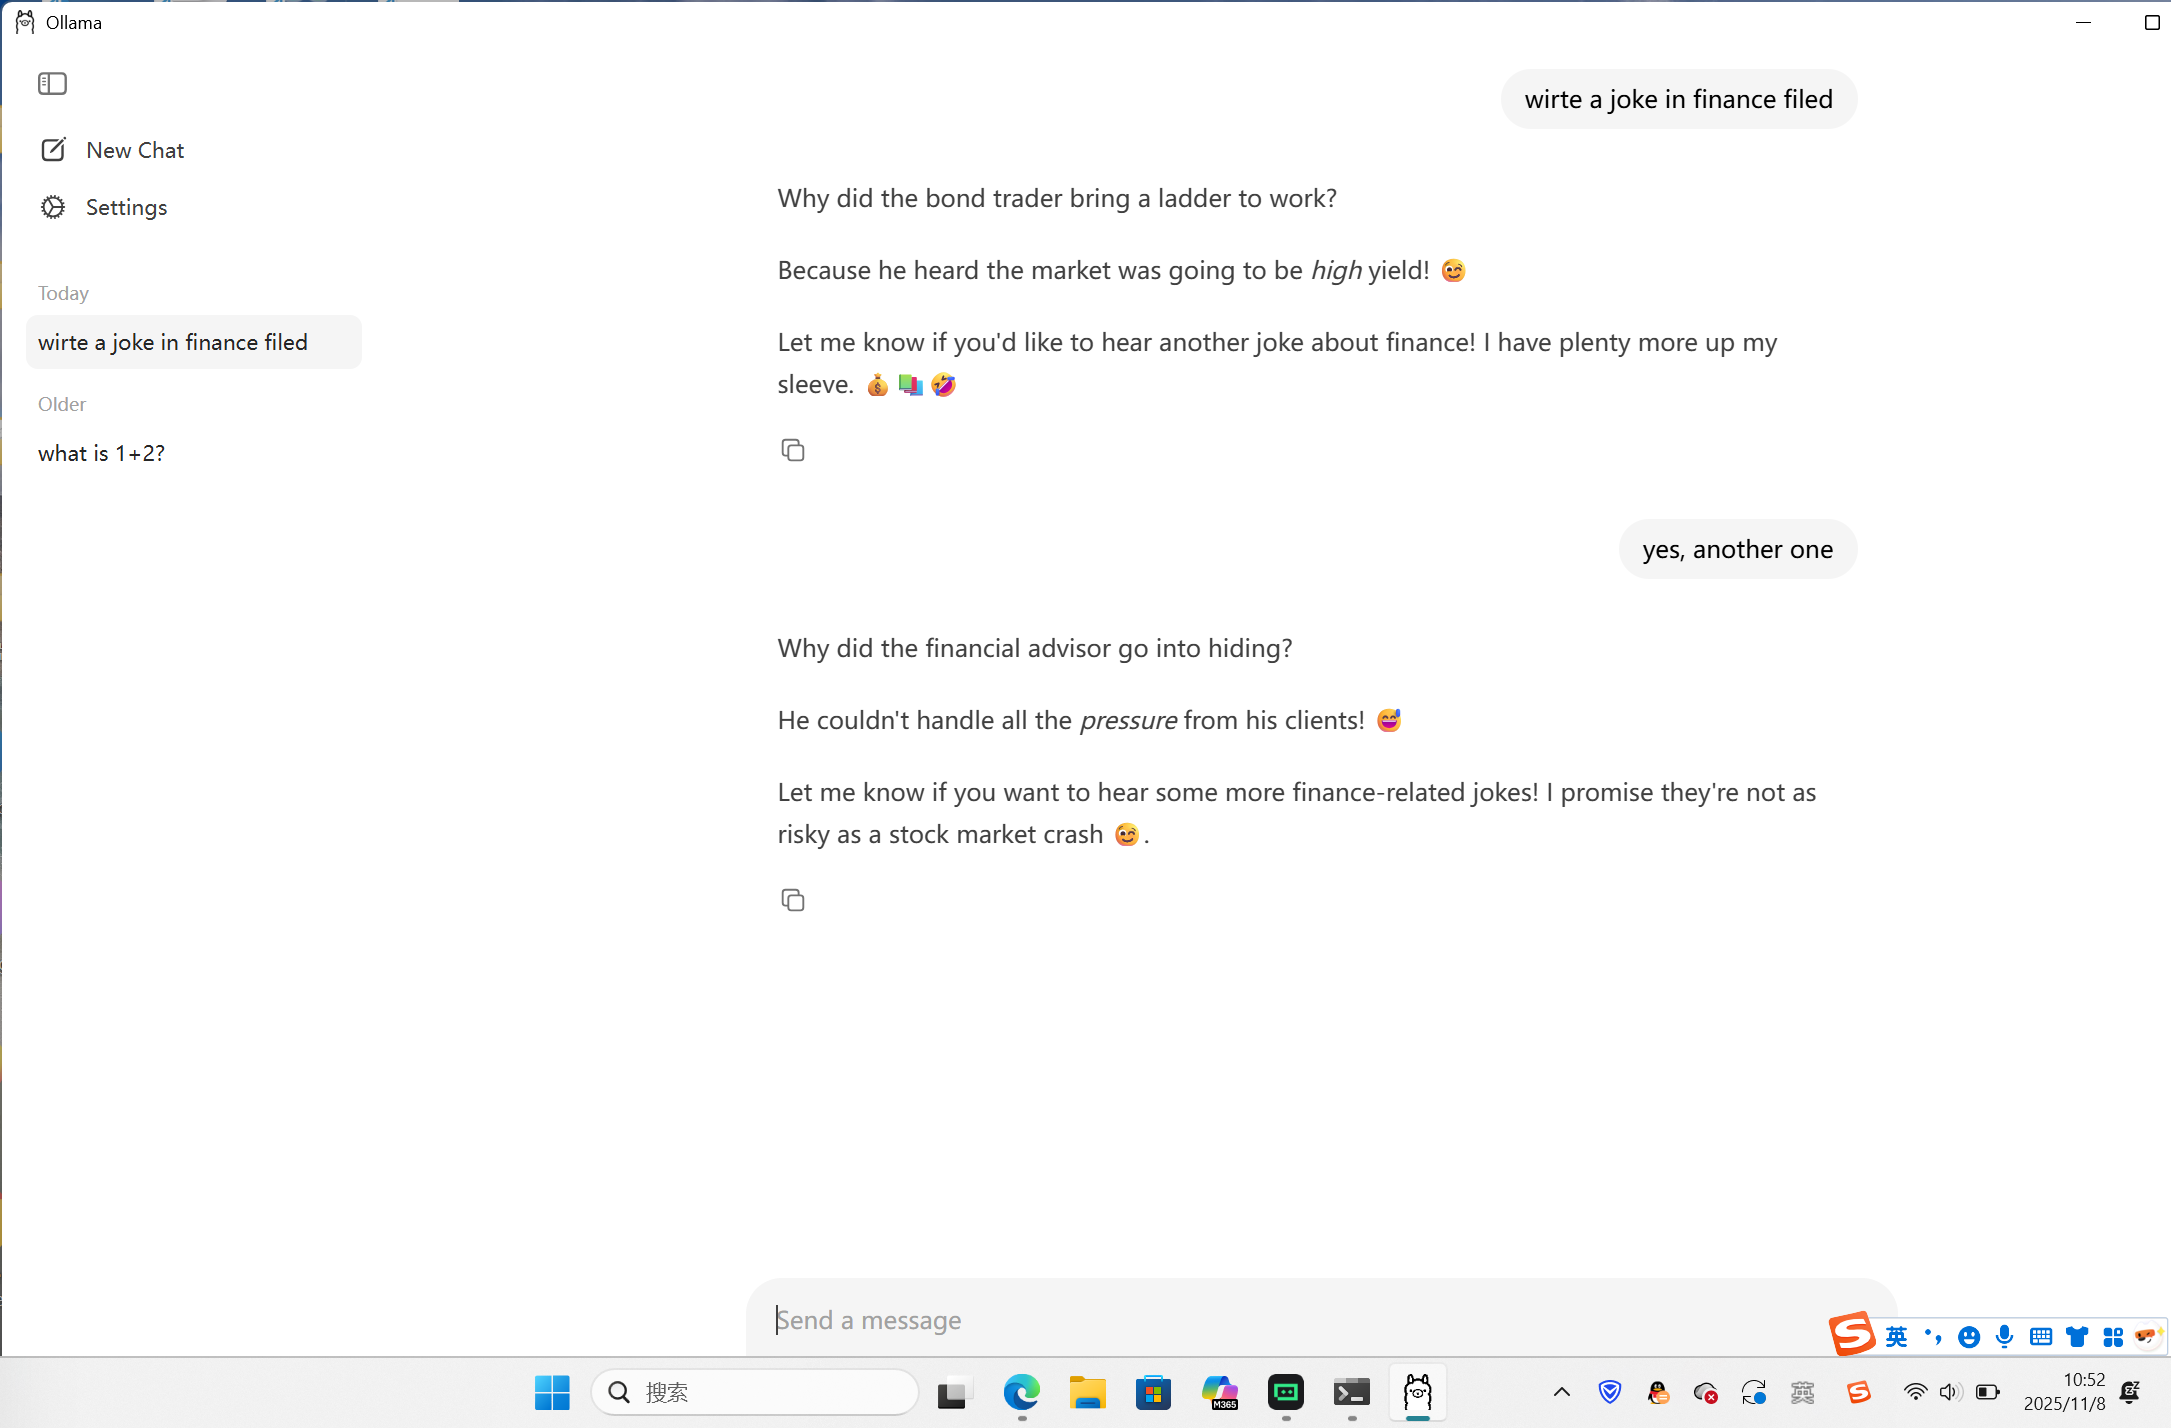

# 在命令行交互使用大模型

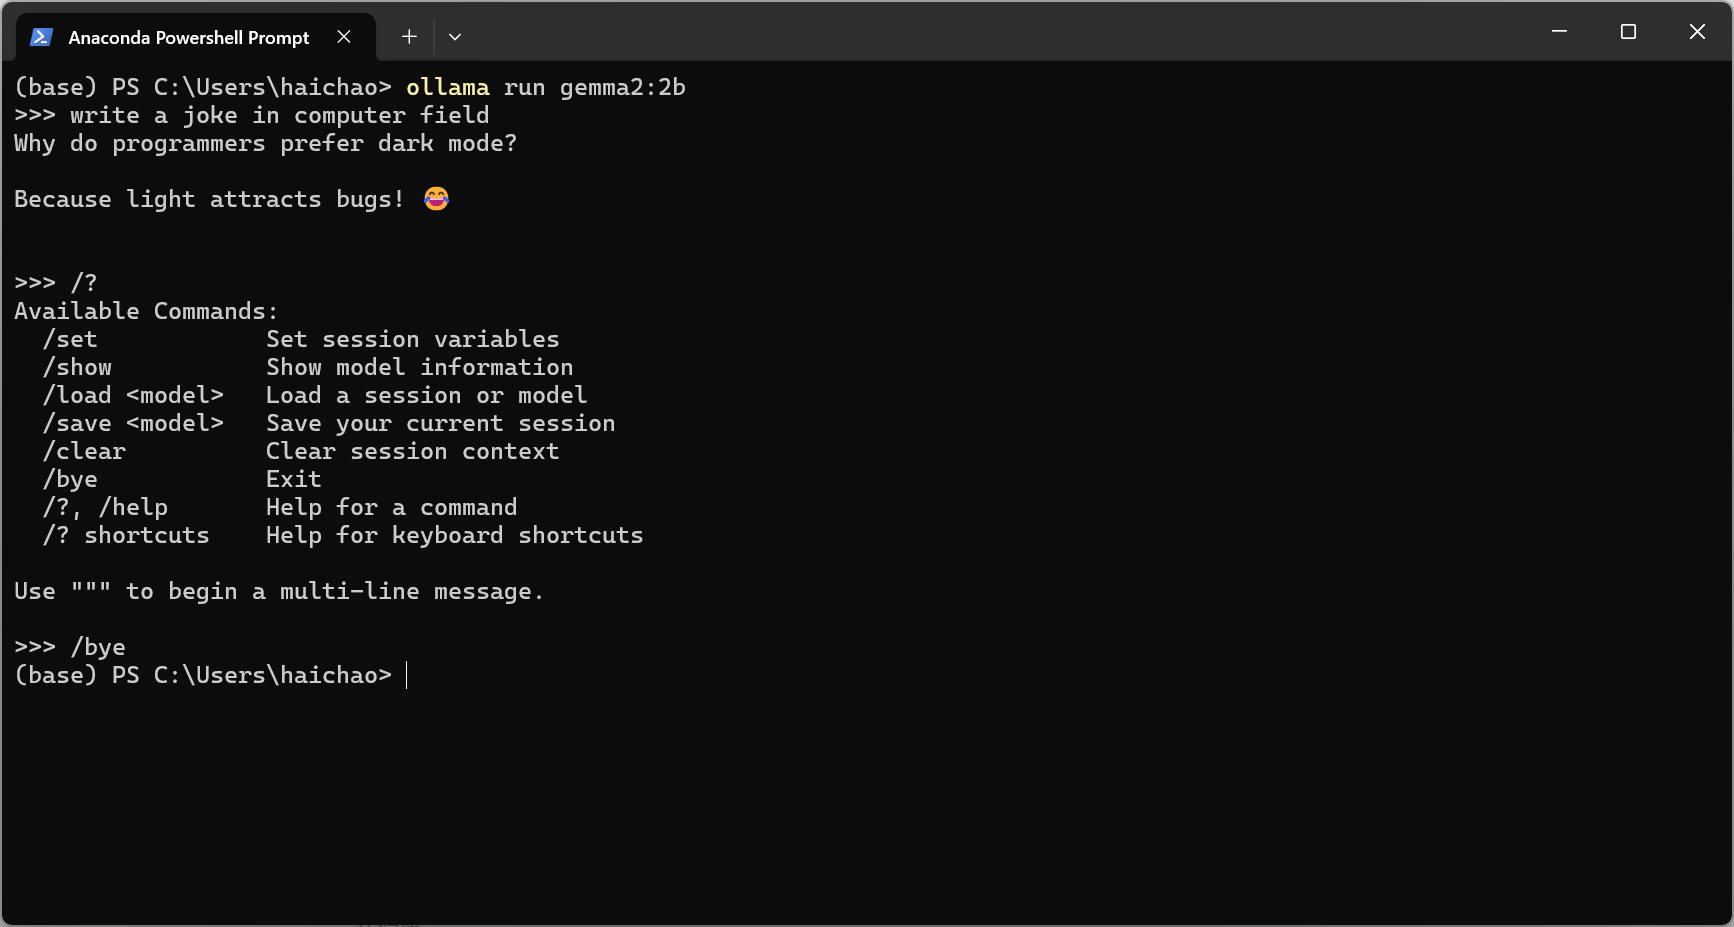

# chat

要先启动 Ollama 服务
- 打开命令行窗口
- 输入 `ollama serve`
- 等待服务启动完成

In [3]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='gpt-oss:20b', messages=[
  {
    'role': 'user',
    'content': 'write a joke in programing filed?',
  },
])

In [4]:
response

ChatResponse(model='gpt-oss:20b', created_at='2025-11-13T09:16:35.5799834Z', done=True, done_reason='stop', total_duration=38531182000, load_duration=201518300, prompt_eval_count=75, prompt_eval_duration=10836816200, eval_count=250, eval_duration=27280481400, message=Message(role='assistant', content='Here’s a classic one that always gets a laugh (or a groan) from developers:\n\n> **Why did the programmer quit his job?**  \n> **Because he didn\'t get arrays!**\n\nAnd a quick code‑style version for fun:\n\n```python\ndef quit_job(programmer):\n    if not programmer.get(\'arrays\'):\n        raise Exception("No arrays, no career!")\n```\n\nHappy coding!', thinking='The user: "write a joke in programing filed?" Means "write a joke in programming field?" They want a programming joke. Likely a pun or something. We can provide a joke. Should be succinct. Possibly a short joke about programming. Maybe incorporate code snippet. They didn\'t ask for a specific programming language. But likely w

In [5]:
print(response['message']['content'])
# or access fields directly from the response object
print(response.message.content)

Here’s a classic one that always gets a laugh (or a groan) from developers:

> **Why did the programmer quit his job?**  
> **Because he didn't get arrays!**

And a quick code‑style version for fun:

```python
def quit_job(programmer):
    if not programmer.get('arrays'):
        raise Exception("No arrays, no career!")
```

Happy coding!
Here’s a classic one that always gets a laugh (or a groan) from developers:

> **Why did the programmer quit his job?**  
> **Because he didn't get arrays!**

And a quick code‑style version for fun:

```python
def quit_job(programmer):
    if not programmer.get('arrays'):
        raise Exception("No arrays, no career!")
```

Happy coding!


# stream

In [11]:
from ollama import chat

stream = chat(
  model='gpt-oss:20b',
  messages=[{'role': 'user', 'content': 'write a joke for a baby?'}],
  stream=True,
)

in_thinking = False
content = ''
thinking = ''
for chunk in stream:
  if chunk.message.thinking:
    if not in_thinking:
      in_thinking = True
      print('Thinking:\n', end='', flush=True)
    print(chunk.message.thinking, end='', flush=True)
    # accumulate the partial thinking 
    thinking += chunk.message.thinking
  elif chunk.message.content:
    if in_thinking:
      in_thinking = False
      print('\n\nAnswer:\n', end='', flush=True)
    print(chunk.message.content, end='', flush=True)
    # accumulate the partial content
    content += chunk.message.content

  # append the accumulated fields to the messages for the next request
  new_messages = [{ "role": 'assistant', "thinking": thinking, "content": content }]

Thinking:
We need to write a joke suitable for a baby. Should be simple, silly, perhaps on baby-friendly themes. Something like "Why did the baby bring a ladder to the nursery? Because it wanted to reach the high snacks!" But babies don't understand ladder. We can make it simple: "What do you call a baby with a broken arm? A baby with a 'toddler'?" Hmm.

Baby jokes often use simple puns like "Why did the baby go to the hospital? To get a 'naptime' injection." Actually we can do "Why did the baby blush? Because it saw the diaper." But that might be too sensitive.

Better: "What did the baby say when it saw its reflection? 'Moo!' (as a cow baby)."

Maybe better: "What do you call a baby who has learned to read? A 'book' baby." Actually "book baby" is a phrase. So "What do you call a baby that reads? A 'book baby'!"

Another simple one: "Why do babies keep their toys in the fridge? Because they like cold 'cuddles'." Eh.

Let's aim for a silly, safe, baby-appropriate joke. Something like:


In [8]:
print(new_messages[0].get("content"))

**Why did the baby bring a blanket to the playground?**  
Because it heard the swings were *so* cozy!  

(Just a silly play‑on‑words that keeps the giggles coming!)


# embedding

https://ai4science.feishu.cn/wiki/LjPowcRTHiOu9wkuYDicw8FmnHf


embeddinggemma

https://ollama.com/library/embeddinggemma

In [ ]:
from ollama import embeddings
import numpy as np
from numpy import dot
from numpy.linalg import norm

# 1. 定义一组测试词汇（包含不同类别和相似度的词汇）
words = [
    "人工智能", "机器学习", "深度学习",  # 技术相关词汇
    "计算机", "手机", "平板",              # 电子产品类别
    "北京", "上海", "深圳",              # 城市名称
    "苹果", "香蕉", "橙子",              # 水果类别
    "金融", "银行", "投资"               # 金融相关词汇
]

# 2. 获取词向量
print("正在获取词向量...")
word_embeddings = {}
for word in words:
    # 使用Ollama获取词向量
    response = embeddings(model="embeddinggemma", prompt=word)
    # 存储词向量
    word_embeddings[word] = response["embedding"]
print(f"成功获取 {len(word_embeddings)} 个词向量")

# 3. 计算余弦相似度函数
def cosine_similarity(vec1, vec2):
    # 计算两个向量的余弦相似度
    return dot(vec1, vec2) / (norm(vec1) * norm(vec2))

# 4. 计算所有词汇对的相似度
print("\n词汇相似度矩阵：")
print("-" * 50)
print(f"{'词汇对':<20} {'相似度':>10}")
print("-" * 50)

# 计算所有可能的词汇对（避免重复计算）
similarities = []
for i in range(len(words)):
    for j in range(i+1, len(words)):
        word1 = words[i]
        word2 = words[j]
        # 计算相似度
        sim = cosine_similarity(word_embeddings[word1], word_embeddings[word2])
        similarities.append((word1, word2, sim))
        print(f"{word1} vs {word2:<10} {sim:.6f}")

# 5. 找出最相似和最不相似的词汇对
similarities.sort(key=lambda x: x[2], reverse=True)
print("\n-" * 2)
print("最相似的5对词汇：")
for i, (w1, w2, sim) in enumerate(similarities[:5]):
    print(f"{i+1}. {w1} vs {w2}: {sim:.6f}")

print("\n最不相似的5对词汇：")
for i, (w1, w2, sim) in enumerate(similarities[-5:]):
    print(f"{i+1}. {w1} vs {w2}: {sim:.6f}")

# 6. 按类别展示相似度示例
print("\n-" * 2)
print("按类别对比示例：")
print(f"人工智能 vs 机器学习: {cosine_similarity(word_embeddings['人工智能'], word_embeddings['机器学习']):.6f}")
print(f"苹果 vs 香蕉: {cosine_similarity(word_embeddings['苹果'], word_embeddings['香蕉']):.6f}")
print(f"北京 vs 上海: {cosine_similarity(word_embeddings['北京'], word_embeddings['上海']):.6f}")
print(f"人工智能 vs 苹果: {cosine_similarity(word_embeddings['人工智能'], word_embeddings['苹果']):.6f}")  # 跨类别

# 应用embedding计算job文本的嵌入

In [ ]:
from ollama import embeddings
import numpy as np
from numpy import dot
from numpy.linalg import norm

# 1. 定义一组测试词汇（包含不同类别和相似度的词汇）
words = [
    "人工智能", "机器学习", "深度学习",  # 技术相关词汇
    "计算机", "手机", "平板",              # 电子产品类别
    "北京", "上海", "深圳",              # 城市名称
    "苹果", "香蕉", "橙子",              # 水果类别
    "金融", "银行", "投资"               # 金融相关词汇
]

def get_embedding(text):
    response = embeddings(model="embeddinggemma", prompt=text)
    embeding = np.array(response["embedding"])
    return embeding

In [ ]:
resume = """我爱好机器学习，我的专长是做算法分析和编程，
            我有金融数据分析与可视化方面的项目经验，
            我期望的工作是在产品研发中做算法设计"""

em_resume = get_embedding("我爱好机器学习，我的专长是做算法分析和编程")

In [ ]:
with open("jobs/job1.txt", "r", encoding = "utf-8") as f:
    job1 = f.read()
job1

In [ ]:
em_job1 = get_embedding(job1)

In [ ]:
em_job1

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
cosine_similarity(em_job1.reshape(1,-1),em_resume.reshape(1,-1))

# 课堂练习
- 使用嵌入大模型
- 计算简历和所有job的相关度

核心代码如下：

```python
# 开始编程
# 正确初始化一个 8×768 的二维数组
em_jobs = np.empty((8, 768))  

for i in range(8):
    # 计算每个岗位与简历的余弦相似度
    # 读取岗位描述
    ...
    # 计算余弦相似度
    em_job ...
    em_jobs[i] ...

sim = cosine_similarity(em_jobs, em_resume.reshape(1,-1))  # 可选优化：只计算已处理的向量
print(sim)
```

In [ ]:
# 开始编程






# output format

In [ ]:
from ollama import chat

response = chat(
  model='gemma2:2b',
  messages=[{'role': 'user', 'content': 'Tell me about SWUFE. the response use json format with keys: introduction, location, and website'}],
  format='json'
)
print(response.message.content)

In [ ]:
from ollama import chat
from pydantic import BaseModel

class Country(BaseModel):
  name: str
  capital: str
  languages: list[str]

response = chat(
  model='gemma2:2b',
  messages=[{'role': 'user', 'content': 'Tell me about China.'}],
  format=Country.model_json_schema(),
)

In [ ]:
print(response.message.content)

In [ ]:
country = Country.model_validate_json(response.message.content)

In [ ]:
country

# 课堂练习：
- 读取股吧评论数据，并使用ollam做情感分析格式化的输出
- 正面评论为1，负面评论为-1，其他为0
- 汇总证明评论与负面评论个数
- sse_comments.txt前20条评论

In [ ]:
from ollama import chat
from pydantic import BaseModel

class Sentiment(BaseModel):
    comment: str
    sentiment_score: int

```python
#   model='gemma2:2b',
#   messages=[{'role': 'user', 'content': '请给下面一条股吧评论打分（正面评论为1，负面评论为-1，其他为0）。评论：明天要大涨了'}],
#   format=Sentiment.model_json_schema(),
```

In [ ]:
# 开始编程






# 思考
- 我们使用ollama做金融文本分析有什么优缺点？